### Libraries

In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import geotherm_calculator as gc
import habitability_calculator as hc
import planetary_grid_reader as pgr

from astropy import constants as const

### Constants

In [3]:
Gpa = 1e9
Mpa = 1e6
km = 1e3
to = 1.332e9 #Terrestrial Oceans volume in km3

Me = const.M_earth.value # Earth mass (kg) 
Re = const.R_earth.value # Earth radius (m) 
G = const.G.value # Gravitational constant (m³ kg⁻¹ s⁻²)

### Plot Config

In [10]:
plt.rcParams.update({
        "font.size": 12,
        "font.family": "serif",
        "axes.labelsize": 13,
        "axes.titlesize": 14,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "axes.linewidth": 1.2,
    })

### HC Composition

In [4]:
mineral_objects = gc.get_mineral_objects()
rocks = gc.prepare_rocks_dict(mineral_objects=mineral_objects)
upper = rocks['upper']

### Eirenesphere Volume ($V_{ES}$)

In [5]:
def VES(a,
             rocks,
             R_planet,
             M_planet,
             qs,
             hr=10e3,
             A_surface=2.5e-6,
             P_top=1e5,
             rho_top=2800.0,
             dz = 100.0
             ):
    

    T_surf = hc.T_eq(a, tau= 0.22)
    
    df_geotherm = gc.calculate_geotherm(
        rocks=rocks,
        q_s=qs,           # 65 mW/m²
        z_max=10e3,         # 10 km 
        dz=dz,           
        R_planet=R_planet,
        M_total=M_planet,
        boundaries=gc.scale_layer_boundaries(R_planet=R_planet),
        T_top=T_surf,
        P_top=P_top,
        A_surface=A_surface,
        rho_top=rho_top,
        h_r=hr
    )
    
    liquid_zone_data = hc.find_liquid_zone(df_geotherm, salinity=0.0, information=False)
    
    if liquid_zone_data['liquid_zone'] is not None:
        habitable_zone_data = hc.find_habitable_zone(liquid_zone_data['indices'], df_geotherm, information=False)
        
        liq_top = liquid_zone_data['liquid_zone'][0]
        liq_bot = liquid_zone_data['liquid_zone'][-1]
        liq_thickness = (liq_bot - liq_top)

        # Geometric Volume 
        r_top = R_planet - liq_top
        r_bot = R_planet - liq_bot

        volume_liquid = (4/3) * np.pi * (r_top**3 - r_bot**3)
        
        
        # Effective Volume
        liq_indices = liquid_zone_data['indices']
        liq_df = df_geotherm.iloc[liq_indices]
        depths_liq = liq_df['depth_m'].values
        phi_liq = liq_df['phi'].values
        

        radii_liq = R_planet - depths_liq
        dV_liq = 4 * np.pi * radii_liq**2 * dz
        volume_liquid_eff = np.sum(phi_liq * dV_liq)

        if habitable_zone_data is not None and habitable_zone_data['habitable_zone'] is not None:
            bio_top = habitable_zone_data['habitable_zone'][0]
            bio_bot = habitable_zone_data['habitable_zone'][-1]
            bio_thickness = (bio_bot - bio_top)

            # Habitable Geometric Volume
            volume_habitable = (4/3) * np.pi * (R_planet**3 - (R_planet - bio_thickness)**3)
            
            # Habitable Effective Volume
            bio_indices = habitable_zone_data['indices']
            bio_df = df_geotherm.iloc[bio_indices]
            depths_bio = bio_df['depth_m'].values
            phi_bio = bio_df['phi'].values

            radii_bio = R_planet - depths_bio
            dV_bio = 4 * np.pi * radii_bio**2 * np.diff(depths_bio, prepend=depths_bio[0])
            volume_habitable_eff = np.sum(phi_bio * dV_bio)
        else:
            bio_thickness = 0.0
            volume_habitable = 0.0
            volume_habitable_eff = 0.0

    else:
        liq_thickness = 0.0
        bio_thickness = 0.0
        volume_liquid = 0.0
        volume_habitable = 0.0
        volume_liquid_eff = 0.0
        volume_habitable_eff = 0.0

    return {
        'liquid_thickness_km': liq_thickness / 1000,
        'habitable_thickness_km': bio_thickness / 1000,
        'liquid_volume_km3': volume_liquid / 1e9,
        'habitable_volume_km3': volume_habitable / 1e9,
        'liquid_volume_eff_km3': volume_liquid_eff / 1e9,
        'habitable_volume_eff_km3': volume_habitable_eff / 1e9,
    }

In [8]:
#Earth Scenario
VES_earth = VES(1, 
                rocks,
                Re,
                Me,
                qs=65e-3,
                A_surface=gc.A0(q_surface=65e-3))

liquid_volume_earth = VES_earth.get('liquid_volume_km3', 0.0)
habitable_volume_earth = VES_earth.get('habitable_volume_km3', 0.0)
liquid_volume_eff_earth = VES_earth.get('liquid_volume_eff_km3', 0.0)
habitable_volume_eff_earth = VES_earth.get('habitable_volume_eff_km3', 0.0)

print("\n Geometric Volume:")
print(f"  Aquability Layer:   {liquid_volume_earth:.2e} km³ = {liquid_volume_earth/to:.2f} to")
print(f"  Eirenesphere: {habitable_volume_earth:.2e} km³ = {habitable_volume_earth/to:.2f} to")
print("\n Effective Volume:")
print(f"  Aquability Layer:   {liquid_volume_eff_earth:.2e} km³ = {liquid_volume_eff_earth/to:.2f} to")
print(f"  Eirenesphere: {habitable_volume_eff_earth:.2e} km³ = {habitable_volume_eff_earth/to:.2f} to")
print("\n Mean Porosity:")
print(f"  Aquability Layer:   {liquid_volume_eff_earth/liquid_volume_earth:.1%}")
print(f"  Eirenesphere: {habitable_volume_eff_earth/habitable_volume_earth:.1%}")
print("="*70)


 Geometric Volume:
  Aquability Layer:   3.83e+09 km³ = 2.88 to
  Eirenesphere: 3.47e+09 km³ = 2.61 to

 Effective Volume:
  Aquability Layer:   1.47e+08 km³ = 0.11 to
  Eirenesphere: 1.38e+08 km³ = 0.10 to

 Mean Porosity:
  Aquability Layer:   3.8%
  Eirenesphere: 4.0%


### $V_{ES}$ for different masses

In [9]:
Masses = np.linspace(0.1, 10, 100) * Me
qs = 65e-3
z_max = 20e3

VESs = np.zeros((len(Masses)), dtype=object)

for i, M in enumerate(Masses):
    
    radius = gc.mass_to_radius(M_planet=Masses[i])
    Ptop = gc.surface_pressure(M_planet = Masses[i])
    hr = gc.scale_hr(M_planet=Masses[i], R_planet=radius)
    A_surf = gc.A0(q_surface=qs, D=hr)
    
    VESs[i] = VES(
        a=1, 
        rocks=rocks,
        R_planet=radius,
        M_planet=M,
        qs=qs,
        hr=hr,
        A_surface=A_surf,
        P_top=Ptop,
        rho_top=2800.0,
        dz=100.0
    )

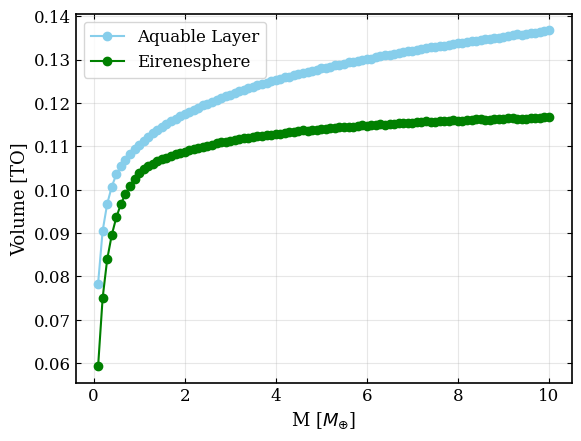

<Figure size 1500x500 with 0 Axes>

In [12]:
liquid_volumes = np.array([V['liquid_volume_km3'] for V in VESs])
habitable_volumes = np.array([V['habitable_volume_km3'] for V in VESs])
liquid_volumes_eff = np.array([V['liquid_volume_eff_km3'] for V in VESs])
habitable_volumes_eff = np.array([V['habitable_volume_eff_km3'] for V in VESs])

plt.plot(Masses/Me, liquid_volumes_eff/to, label='Aquable Layer', color='skyblue', marker='o')
plt.plot(Masses/Me, habitable_volumes_eff/to, label='Eirenesphere', color='green', marker='o')
plt.ylabel('Volume [TO]')
plt.xlabel('M [$M_⊕$]')
plt.legend()
plt.grid(alpha=0.3)
plt.legend()
plt.figure(figsize=(15, 5))
plt.show()

## Eirenesphere Volumetric Index (EVI)

### Scaling Functions


In [14]:
def mass_to_radius(M_planet, 
                   M_ref=Me, 
                   R_ref=Re):
    """
    Masa-radio para planetas rocosos tipo Tierra.
    Válido hasta ~5-6 M⊕
    """
    gamma = 0.27
    return R_ref * (M_planet / M_ref)**gamma

def surface_pressure(M_planet,
                     M_ref=Me,
                     P0_ref=1.01325e5):
    """
    Escala la presión atmosférica superficial para planetas tipo Tierra.
    
    p0 ∝ M^0.92  (atmósfera tipo Tierra)
    """
    return P0_ref * (M_planet / M_ref)**0.92

def scale_hr(M_planet,
             R_planet,
             M_ref=Me,
             R_ref=Re,
             hr_ref=10e3):
    """
    Escalado del scale height radiogénico h_r.

    Parameters
    ----------
    M_planet : float
        Masa del planeta en masas terrestres (M/M_earth)
    R_planet : float
        Radio del planeta en radios terrestres (R/R_earth)
    hr_ref : float
        Scale height terrestre en km (default = 10 km)

    Returns
    -------
    h_r : float
        Scale height radiogénico en km
    """

    h_r = hr_ref * ((R_planet/R_ref)**2 / (M_planet/M_ref))
    return h_r

### Auxiliary EVI Functions

In [26]:

def EVI_Index(M_planet, qs, rocks, a_search_in=0.1, a_search_out=20.0, N=100):
    Rp = mass_to_radius(M_planet)
    Ptop = surface_pressure(M_planet)
    hr = scale_hr(M_planet, Rp)
    A_surf = gc.A0(q_surface=qs, D=hr)

    # Grid amplio para escanear y encontrar la SSHZ
    ds_search = np.linspace(a_search_in, a_search_out, N)
    Vhabs = np.zeros_like(ds_search)

    has_entered_sshz = False
    tol = 1e-4
    for i, d in enumerate(ds_search):
        V_3D = VES(d,
                        rocks,
                        Rp,
                        M_planet,
                        qs,
                        hr=hr,
                        P_top=Ptop,
                        A_surface=A_surf)
        
        habitable_volume = V_3D.get('habitable_volume_eff_km3', 0.0)
        Vhabs[i] = habitable_volume
        
        if Vhabs[i] > tol:
            has_entered_sshz = True
        elif has_entered_sshz and Vhabs[i] <= tol:
            break  # Salió de la SSHZ, podemos detener la búsqueda
        
        
    valid_indices = np.where(Vhabs > 0)[0]
    
    if len(valid_indices) == 0:
        return [0.0, np.array([]), np.array([])]
        
    idx_min = valid_indices[0]
    idx_max = valid_indices[-1]
    
    a_min_sshz = ds_search[idx_min]
    a_max_sshz = ds_search[idx_max]
    
    if idx_min == 0 or idx_max == N-1:
        print(f"[WARNING] SSHZ may extend beyond the search range: a_min_sshz={a_min_sshz:.3f} au, a_max_sshz={a_max_sshz:.3f} au, Planet mass: {M_planet/Me:.2f} M⊕, qs: {qs*1e3:.1f} mW/m²")
    
    ds_sshz = ds_search[idx_min:idx_max+1]
    Vhabs_sshz = Vhabs[idx_min:idx_max+1]
    delta_a_sshz = a_max_sshz - a_min_sshz
    
    if delta_a_sshz == 0:
        return [0.0, np.array([]), np.array([])]
    
    EVI_value = np.trapz(Vhabs_sshz, ds_sshz)/ delta_a_sshz
    
    return [EVI_value, Vhabs_sshz, ds_sshz]

def EVI_grid(Masses, qss, rocks, a_search_in=0.1, a_search_out=20.0, N=100, cache_file=None):
    
    if cache_file and os.path.exists(cache_file):
        print(f"Reloading cached EVI grid from {cache_file}...")
        with open(cache_file, 'rb') as f:
            return pickle.load(f)

    nM = len(Masses)
    nq = len(qss)
    
    # Creamos dos matrices independientes para no perder el índice efectivo
    grid= np.zeros((nM, nq))

    idx = 0
    for iM, Mp in enumerate(Masses):
        for iq, qs in enumerate(qss):
            evi_val = EVI_Index(Mp, qs, rocks, a_search_in, a_search_out, N=N)[0]
            
            grid[iM, iq] = evi_val
            
            print(f"EVI calculation progress: {idx+1}/{nM*nq}", end='\r')
            idx += 1

    result = {
        'mass_array': np.array(Masses),
        'qs_array': np.array(qss),
        'EVI_grid': grid,          
    }

    if cache_file:
        with open(cache_file, 'wb') as f:
            pickle.dump(result, f)

    return result

def plot_EVI_heatmap(result, mass_unit='Me', cmap='viridis',
                     qs_evo = None,
                     log_scale=False):
    """
    Plotea heatmap de EVI_grid (eje x: qs, eje y: masa)
    mass_unit: 'Me' para mostrar masas en Earth masses (Mp/Me)
    
    """

    mass_array = result['mass_array']
    qs_array = result['qs_array']
    EVI_grid = result['EVI_grid']/to

    if mass_unit == 'Me':
        y_ticks = mass_array / Me
        y_label = 'M [$M_⊕$]'
    else:
        y_ticks = mass_array
        y_label = 'M [kg]'
    
    X, Y = np.meshgrid(qs_array*1e3, y_ticks)  # qs en mW/m2 para etiqueta
    
    plt.figure(figsize=(9,5))
    if log_scale:
        pcm = plt.pcolormesh(X, Y, np.log10(EVI_grid), shading='auto', cmap=cmap)
        cbar = plt.colorbar(pcm)
        cbar.set_label(r'$\log_{10}(EVI)$ [km$^3$]')

    else:
        pcm = plt.pcolormesh(X, Y, EVI_grid, shading='auto', cmap=cmap)
        cbar = plt.colorbar(pcm)
        cbar.set_label(r'$EVI$ [TO]')


        

        # Normalizar valor para ubicarlo en la colorbar
        y_star = 0.024

        # Dibujar estrella en la colorbar
        cbar.ax.plot(
            [0.5], [y_star],
            marker='*',
            markersize=10,
            color='red',
            markeredgecolor='black',
            transform=cbar.ax.transAxes,
            zorder=10
        )

    
    #Tierra
    plt.scatter(65, 1.0, color='red', s=150, marker='*', edgecolors='black', linewidths=2,
                label='Earth [65 mW/m², 1 M⊕]', zorder=10)
    
    #linea solo va de 0 a 1 en y, y de 0 a 65 en x
    plt.axhline(y=1.0, color='black', linestyle='--', linewidth=2, alpha=0.7)
    plt.axvline(x=65, color='black', linestyle='--', linewidth=2, alpha=0.7)
    

    if qs_evo is not None:
        planet_mass = 1.0
        plt.plot(qs_evo, [planet_mass]*len(qs_evo), 
                 color='cyan', linewidth=2, linestyle='--',
                 label=f'Earth Thermal evolution [{planet_mass:.1f} M⊕]', zorder=9)
    
    plt.legend(loc='upper right', fontsize=10)
    plt.xlabel('$q_s$ [mW/m²]')
    plt.ylabel(y_label)
    plt.tight_layout()
    plt.show()

### VES for different Masses vs Orbital Distance

In [34]:
Masses = np.array([0.1, 0.5, 1, 2, 5, 10]) * Me

results = [ ]
for m in range(len(Masses)):
    res = EVI_Index(M_planet=Masses[m], qs = 65e-3, rocks=rocks, a_search_in=0.1, a_search_out=5.0)
    results.append(res)

[WARNING] SSHZ may extend beyond the search range: a_min_sshz=0.496 au, a_max_sshz=5.000 au, Planet mass: 0.10 M⊕, qs: 65.0 mW/m²
[WARNING] SSHZ may extend beyond the search range: a_min_sshz=0.496 au, a_max_sshz=5.000 au, Planet mass: 0.50 M⊕, qs: 65.0 mW/m²
[WARNING] SSHZ may extend beyond the search range: a_min_sshz=0.496 au, a_max_sshz=5.000 au, Planet mass: 1.00 M⊕, qs: 65.0 mW/m²


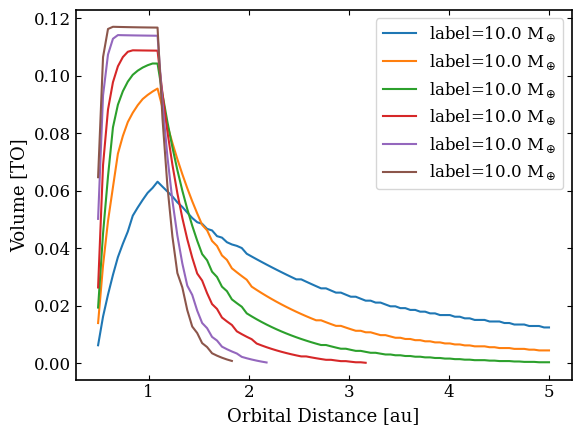

In [46]:
for res in range(len(results)):   
    plt.plot(results[res][2], results[res][1]/to, label = f"label={Masses[m]/Me:.1f} M$_\oplus$")

plt.xlabel("Orbital Distance [au]")
plt.ylabel("Volume [TO]")
plt.legend()
plt.show()

### EVI Analysis

In [24]:
#Earth Scenario
res = EVI_Index(M_planet=Me, qs = 65e-3, rocks=rocks, a_search_in=0.1, a_search_out=5.0)
print(f"Earth EVI: {res[0]/to:.2f}")

[WARNING] SSHZ may extend beyond the search range: a_min_sshz=0.496 au, a_max_sshz=5.000 au, Planet mass: 1.00 M⊕, qs: 65.0 mW/m²
Earth EVI: 0.02


In [17]:
Masses = np.linspace(0.1*Me, 10*Me, 20)  # 0.1 a 10 Earth masses
qss = np.linspace(20e-3, 200e-3, 20)  # 20 a 200 mW/m²

result = EVI_grid(Masses, qss, rocks, a_search_in=0.1, a_search_out=5.0, N=100, cache_file='EVI_cache.pkl')

Reloading cached EVI grid from EVI_cache.pkl...


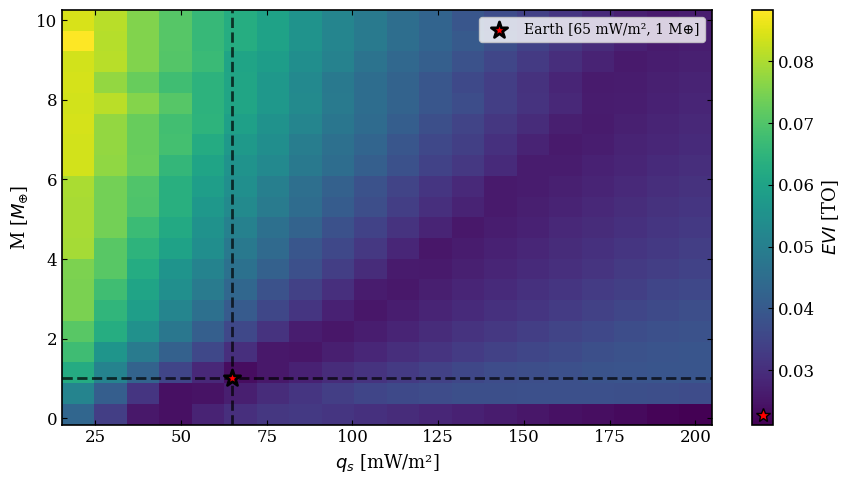

In [27]:
plot_EVI_heatmap(result)

In [33]:
print("\n" + "="*70)
print("EVI - Results")
print("="*70)
print(f"\nParámetros de la simulación:")
print(f"  Rango de masas: {Masses[0]/Me:.1f} - {Masses[-1]/Me:.1f} M⊕")
print(f"  Rango de flujos térmicos: {qss[0]*1e3:.1f} - {qss[-1]*1e3:.1f} mW/m²")
print(f"\nResultados clave:")   
print(f"  I3D máximo en la grilla: {np.max(result['EVI_grid']/to):.2f} to")
print(f"  I3D mínimo en la grilla: {np.min(result['EVI_grid']/to):.2f} to")




EVI - Results

Parámetros de la simulación:
  Rango de masas: 0.1 - 10.0 M⊕
  Rango de flujos térmicos: 20.0 - 200.0 mW/m²

Resultados clave:
  I3D máximo en la grilla: 0.09 to
  I3D mínimo en la grilla: 0.02 to


In [ ]:
Masses = np.linspace(0.1*Me, 10*Me, 20)  # 0.1 a 10 Earth masses
qss = np.linspace(20e-3, 200e-3, 20)  # 20 a 200 mW/m²

EVIs = np.zeros((len(Masses), len(qss)), dtype=object)

idx = 0
for i in range(len(Masses)):
    for j in range(len(qss)):
        EVIs[i, j] = EVI_Index(Masses[i], qss[j], rocks, a_search_in=0.1, a_search_out=5.0, N=100)[0]
        print(f"EVI calculation progress: {idx+1}/{len(Masses)*len(qss)}", end='\r')
        idx += 1